<a href="https://www.kaggle.com/code/avikdas567/multi-gbdt-ensemble-for-student-health-profiling?scriptVersionId=331988419" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Predictive Modeling for Student Health Risk Factors
This notebook delivers an end-to-end classification framework targeting student health risks. The pipeline covers systematic data profiling, custom exploratory data analysis, robust feature engineering, stratified cross-validation, and multi-model tree-based ensembling optimized for T4 GPU execution.


# Environment Setup and Global Initialization
We establish our development environment, declare libraries, and enforce global random seeds to guarantee exact reproducibility across separate framework executions.


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
seed_everything(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
PALETTE = ['#2b5c8f', '#d95f02', '#7570b3', '#e7298a', '#66a61e']
sns.set_palette(PALETTE)


# Data Ingestion and Structural Profiling
We read the source data files and log metadata concerning rows, columns, data types, and null value distributions.


In [2]:
TRAIN_PATH = '/kaggle/input/competitions/playground-series-s6e7/train.csv'
TEST_PATH = '/kaggle/input/competitions/playground-series-s6e7/test.csv'
SUB_PATH = '/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv'

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
submission_df = pd.read_csv(SUB_PATH)

print(f'Train Dataset Dimensions: {train_raw.shape}')
print(f'Test Dataset Dimensions: {test_raw.shape}')
print('\nTrain Features & Information:')
print(train_raw.info())


Train Dataset Dimensions: (690088, 15)
Test Dataset Dimensions: (295753, 14)

Train Features & Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physic

# Advanced Exploratory Data Analysis
We generate ten separate visualizations to explore feature relationships and uncover patterns relative to the target class labels.

## Target Label Frequency Distribution


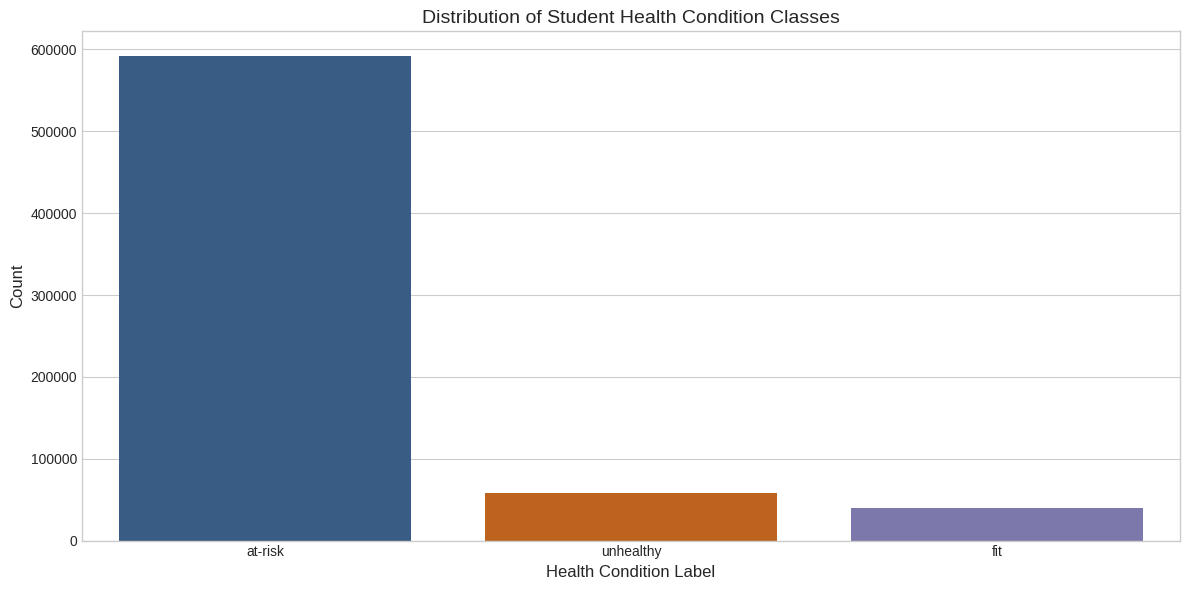

In [3]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_raw, x='health_condition', order=train_raw['health_condition'].value_counts().index, palette=PALETTE)
plt.title('Distribution of Student Health Condition Classes')
plt.xlabel('Health Condition Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## Missing Value Profile Across Splits


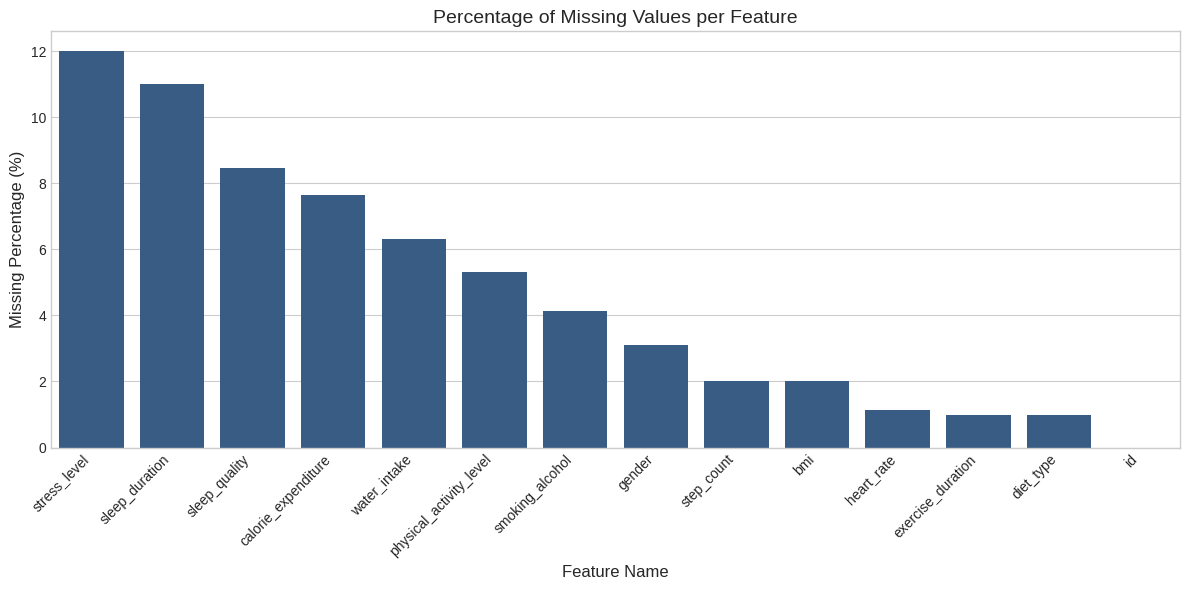

In [4]:
missing_train = train_raw.isnull().mean() * 100
missing_test = test_raw.isnull().mean() * 100
missing_df = pd.DataFrame({'Train Missing %': missing_train, 'Test Missing %': missing_test}).drop('health_condition', errors='ignore')
missing_df = missing_df.sort_values(by='Train Missing %', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df.index, y=missing_df['Train Missing %'], color='#2b5c8f')
plt.xticks(rotation=45, ha='right')
plt.title('Percentage of Missing Values per Feature')
plt.xlabel('Feature Name')
plt.ylabel('Missing Percentage (%)')
plt.tight_layout()
plt.show()


## Sleep Duration Analysis by Target Class


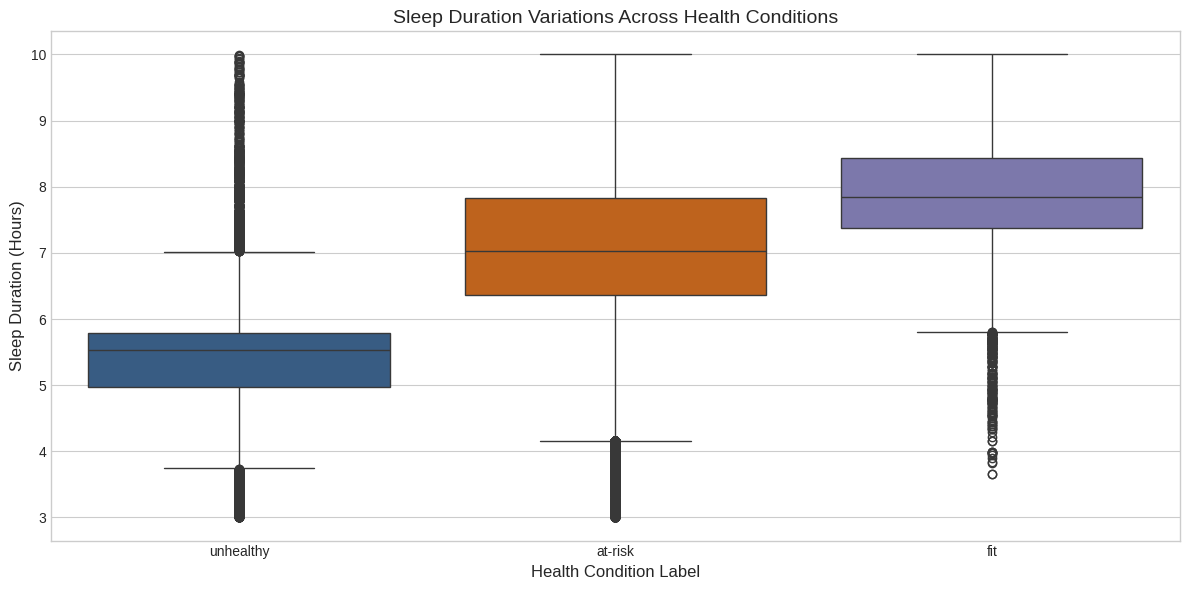

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_raw, x='health_condition', y='sleep_duration', palette=PALETTE)
plt.title('Sleep Duration Variations Across Health Conditions')
plt.xlabel('Health Condition Label')
plt.ylabel('Sleep Duration (Hours)')
plt.tight_layout()
plt.show()


## BMI Variance Across Target Classes


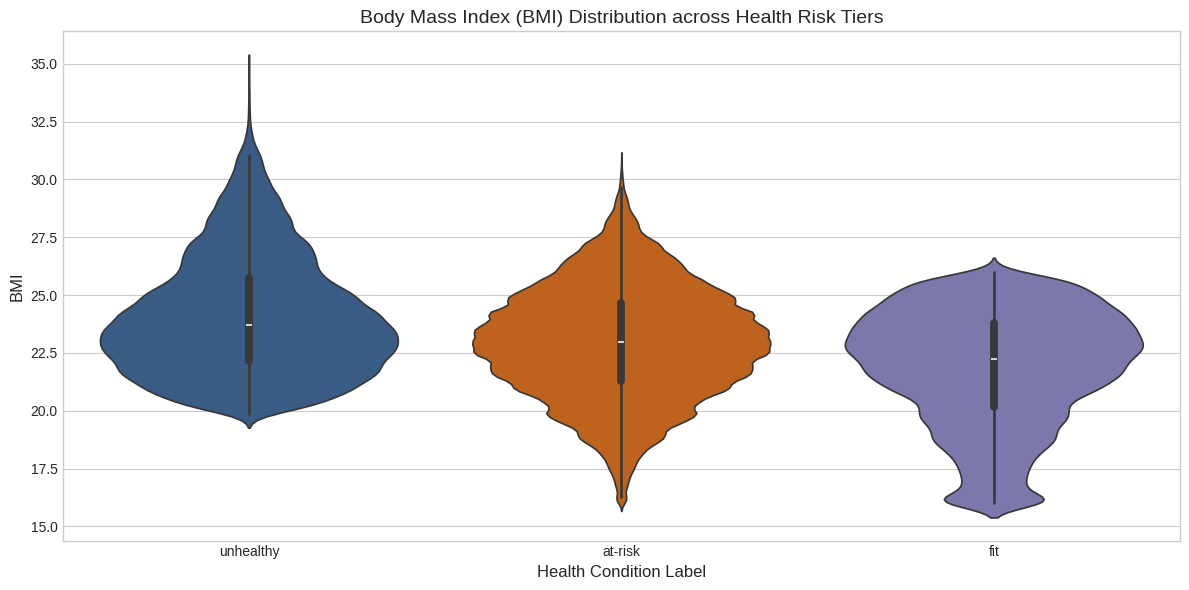

In [6]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=train_raw, x='health_condition', y='bmi', palette=PALETTE)
plt.title('Body Mass Index (BMI) Distribution across Health Risk Tiers')
plt.xlabel('Health Condition Label')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()


## Stress Level Cross-Tabulation


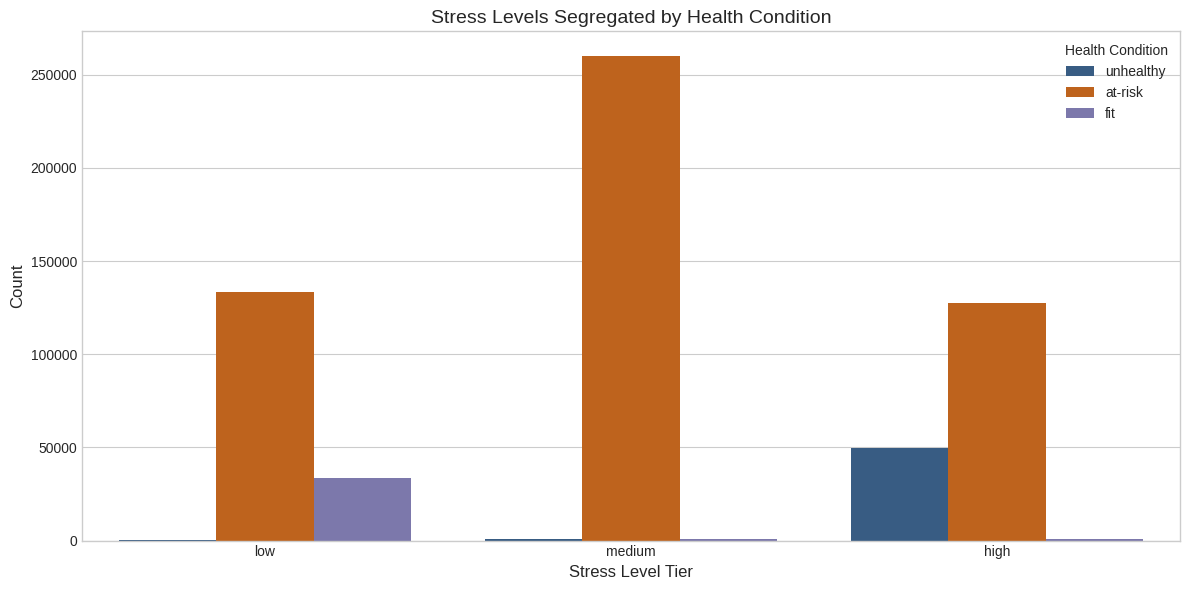

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_raw, x='stress_level', hue='health_condition', order=['low', 'medium', 'high'], palette=PALETTE)
plt.title('Stress Levels Segregated by Health Condition')
plt.xlabel('Stress Level Tier')
plt.ylabel('Count')
plt.legend(title='Health Condition')
plt.tight_layout()
plt.show()


## Sleep Quality vs Health Status


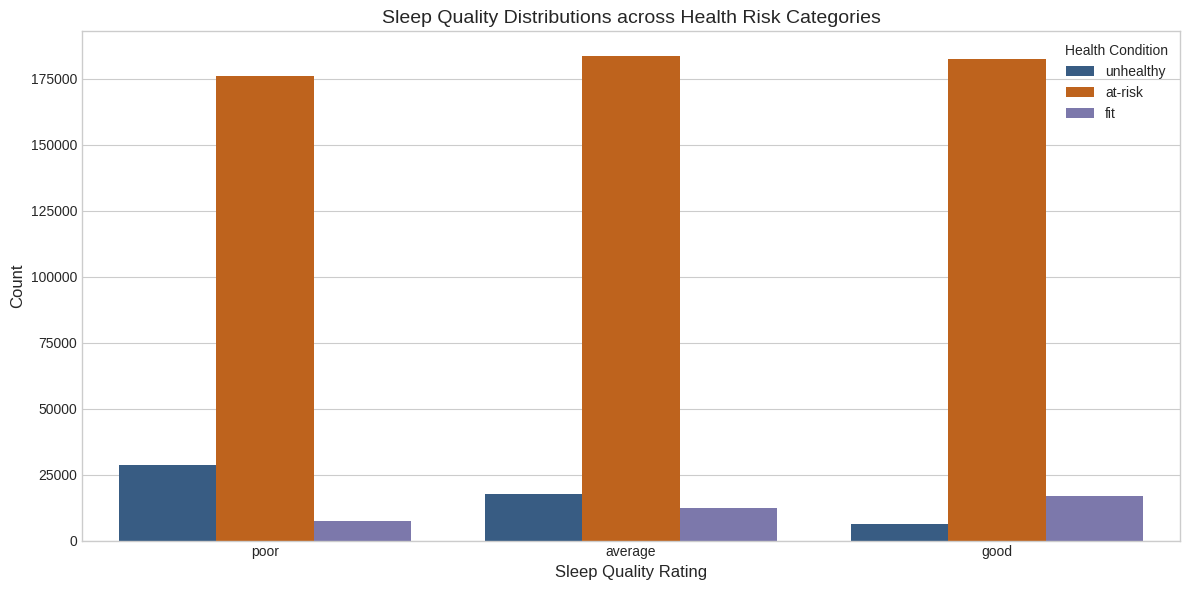

In [8]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_raw, x='sleep_quality', hue='health_condition', order=['poor', 'average', 'good'], palette=PALETTE)
plt.title('Sleep Quality Distributions across Health Risk Categories')
plt.xlabel('Sleep Quality Rating')
plt.ylabel('Count')
plt.legend(title='Health Condition')
plt.tight_layout()
plt.show()


## Physical Activity Interactions


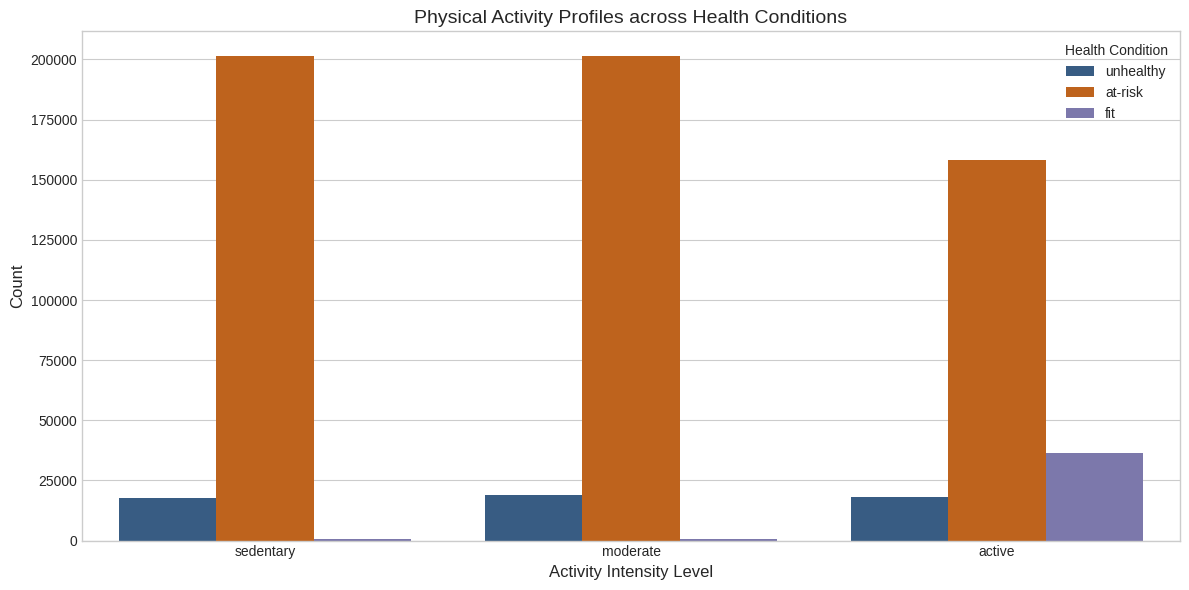

In [9]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_raw, x='physical_activity_level', hue='health_condition', order=['sedentary', 'moderate', 'active'], palette=PALETTE)
plt.title('Physical Activity Profiles across Health Conditions')
plt.xlabel('Activity Intensity Level')
plt.ylabel('Count')
plt.legend(title='Health Condition')
plt.tight_layout()
plt.show()


## Heart Rate Physiological Signal


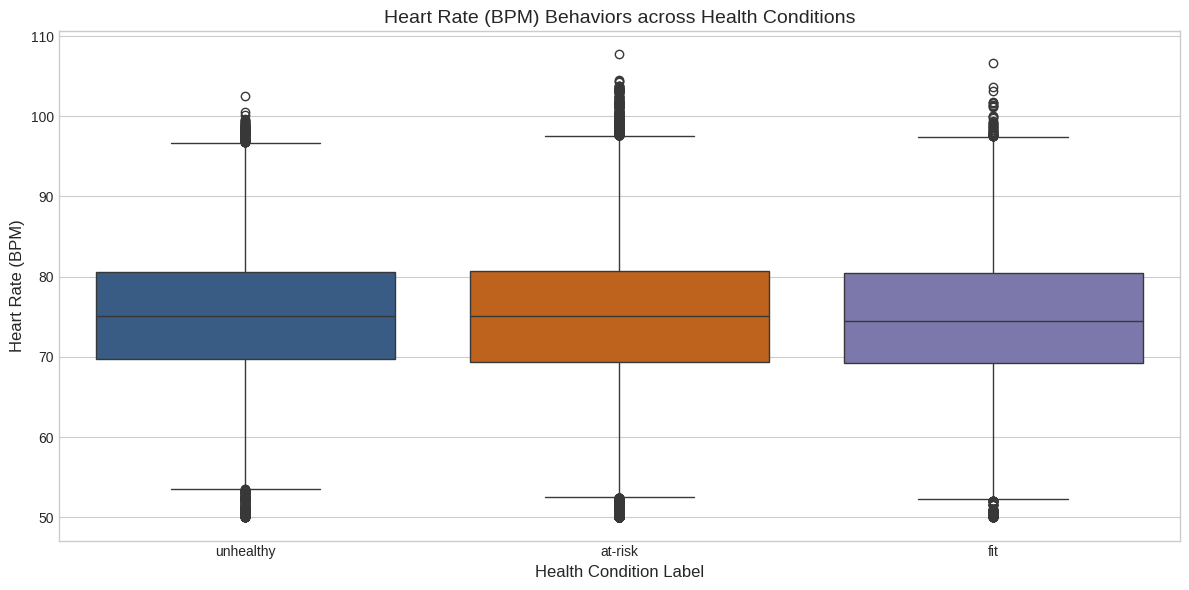

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_raw, x='health_condition', y='heart_rate', palette=PALETTE)
plt.title('Heart Rate (BPM) Behaviors across Health Conditions')
plt.xlabel('Health Condition Label')
plt.ylabel('Heart Rate (BPM)')
plt.tight_layout()
plt.show()


## Step Count Behavioral Tracking


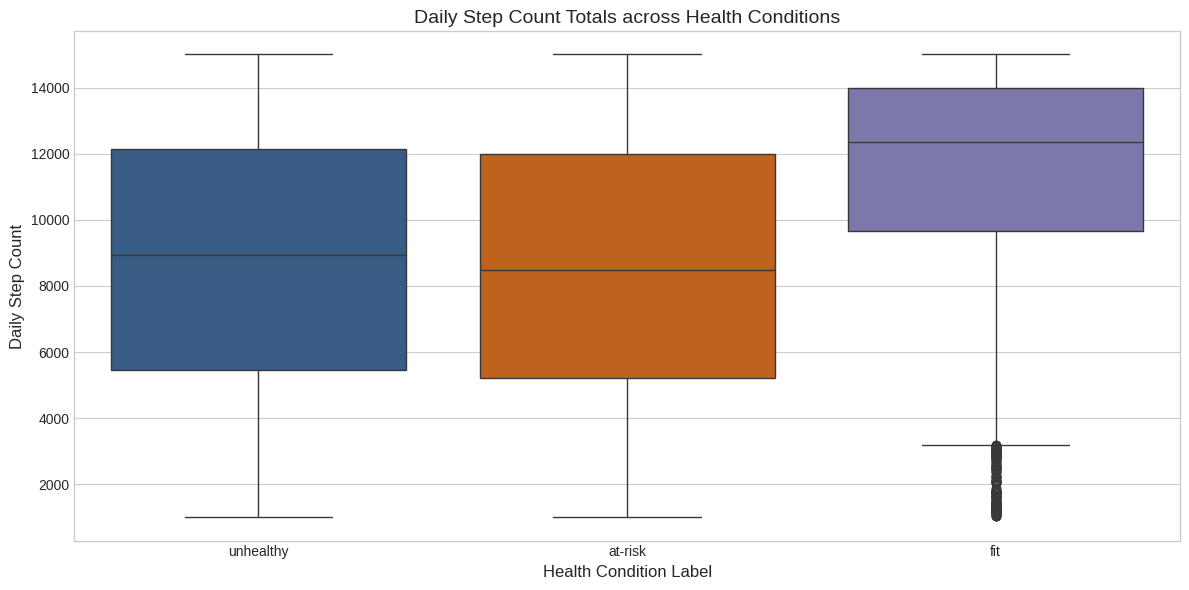

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_raw, x='health_condition', y='step_count', palette=PALETTE)
plt.title('Daily Step Count Totals across Health Conditions')
plt.xlabel('Health Condition Label')
plt.ylabel('Daily Step Count')
plt.tight_layout()
plt.show()


## Continuous Feature Interactions Heatmap


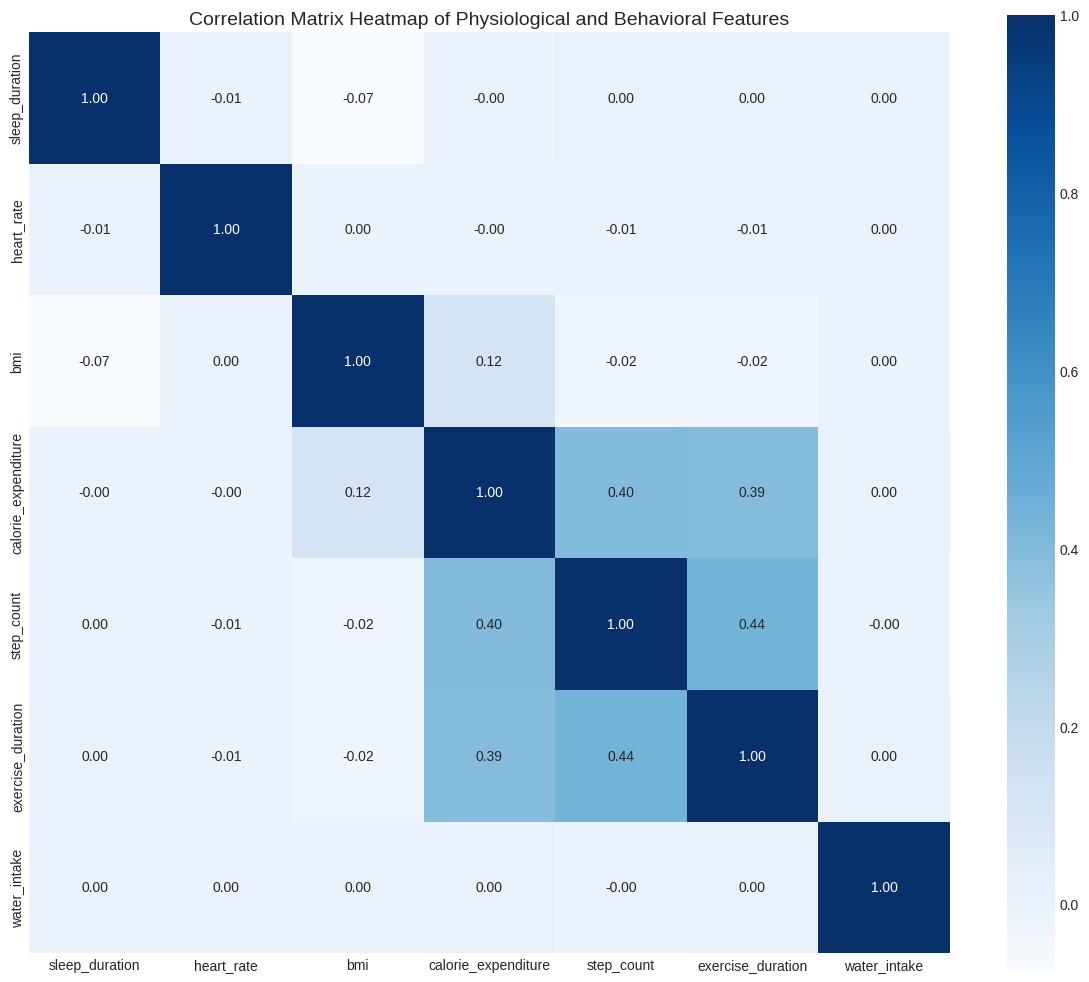

In [12]:
plt.figure(figsize=(12, 10))
numeric_cols = train_raw.select_dtypes(include=['float64', 'int64']).drop('id', axis=1, errors='ignore')
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='Blues', cbar=True, square=True)
plt.title('Correlation Matrix Heatmap of Physiological and Behavioral Features')
plt.tight_layout()
plt.show()


# Preprocessing and Feature Engineering Pipeline
We construct a uniform processing pipeline across both splits. This phase builds binary missingness indicators, creates domain-specific physiological ratios, combines categorical fields into context interaction terms, and encodes categorical sequences cleanly.


In [13]:
# Separate target label and track dataset splits
train_df = train_raw.copy()
test_df = test_raw.copy()
y_train_raw = train_df['health_condition']
train_df = train_df.drop('health_condition', axis=1)

train_df['is_train'] = 1
test_df['is_train'] = 0
combined = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

# 1. Generate Missingness Indicators for Sparse Columns
sparse_cols = ['sleep_duration', 'stress_level', 'sleep_quality', 'calorie_expenditure', 'water_intake']
for col in sparse_cols:
    combined[f'{col}_is_missing'] = combined[col].isnull().astype(int)

# 2. Domain-Specific Interaction Features
combined['sleep_per_step'] = combined['sleep_duration'] / (combined['step_count'] + 1)
combined['calories_per_step'] = combined['calorie_expenditure'] / (combined['step_count'] + 1)
combined['exercise_intensity'] = combined['calorie_expenditure'] / (combined['exercise_duration'] + 1)
combined['cardio_load'] = combined['heart_rate'] * combined['bmi']
combined['hydration_ratio'] = combined['water_intake'] / (combined['calorie_expenditure'] + 1)

# 3. Categorical Interaction Contexts
categorical_cols = ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
for col in categorical_cols:
    combined[col] = combined[col].fillna('missing').astype(str)

combined['stress_sleep'] = combined['stress_level'] + '_' + combined['sleep_quality']
combined['activity_diet'] = combined['physical_activity_level'] + '_' + combined['diet_type']

# Update our tracking array of categorical dimensions
extended_categorical = categorical_cols + ['stress_sleep', 'activity_diet']

# 4. Apply Categorical Label Encoding
for col in extended_categorical:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])

# 5. Split Combined Dataset Back into Train and Test Arrays
features = [c for c in combined.columns if c not in ['id', 'is_train']]
X_train = combined[combined['is_train'] == 1][features].reset_index(drop=True)
X_test = combined[combined['is_train'] == 0][features].reset_index(drop=True)

# Encode the multiclass string target into integers
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train_raw)

print(f'Processed Training Matrix Shape: {X_train.shape}')
print(f'Processed Testing Matrix Shape: {X_test.shape}')


Processed Training Matrix Shape: (690088, 25)
Processed Testing Matrix Shape: (295753, 25)


# Validation Strategy and Model Multi-Framework Configuration
We instantiate a 5-fold Stratified Cross-Validation protocol to enforce balanced target distribution across training iterations. Out-of-fold predictions are collected for evaluation using the competition metric, Balanced Accuracy.


In [14]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Initialize Out-of-Fold (OOF) tracking structures
oof_lgb = np.zeros((len(X_train), 3))
oof_xgb = np.zeros((len(X_train), 3))
oof_cat = np.zeros((len(X_train), 3))

# Initialize Test Prediction tracking structures
preds_lgb = np.zeros((len(X_test), 3))
preds_xgb = np.zeros((len(X_test), 3))
preds_cat = np.zeros((len(X_test), 3))


# LightGBM Framework Cross-Validation Loop
We train our LightGBM model across the 5 stratified splits, computing probabilities for each class label per fold.


In [15]:
lgb_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': 8,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'random_state': SEED,
    'verbose': -1,
    'n_jobs': -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f'\n=== Training LightGBM Model - Fold {fold + 1} / {N_FOLDS} ===')
    X_tr, y_tr = X_train.iloc[train_idx], y_train[train_idx]
    X_va, y_va = X_train.iloc[val_idx], y_train[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params, n_estimators=1000)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    oof_lgb[val_idx] = model.predict_proba(X_va)
    preds_lgb += model.predict_proba(X_test) / N_FOLDS
    
    fold_preds = np.argmax(oof_lgb[val_idx], axis=1)
    fold_score = balanced_accuracy_score(y_va, fold_preds)
    print(f'LightGBM Fold {fold + 1} Balanced Accuracy: {fold_score:.5f}')

oof_lgb_class = np.argmax(oof_lgb, axis=1)
overall_lgb_score = balanced_accuracy_score(y_train, oof_lgb_class)
print(f'\n>> Overall LightGBM Out-of-Fold Balanced Accuracy: {overall_lgb_score:.5f}')



=== Training LightGBM Model - Fold 1 / 5 ===
LightGBM Fold 1 Balanced Accuracy: 0.87582

=== Training LightGBM Model - Fold 2 / 5 ===
LightGBM Fold 2 Balanced Accuracy: 0.87869

=== Training LightGBM Model - Fold 3 / 5 ===
LightGBM Fold 3 Balanced Accuracy: 0.87887

=== Training LightGBM Model - Fold 4 / 5 ===
LightGBM Fold 4 Balanced Accuracy: 0.87444

=== Training LightGBM Model - Fold 5 / 5 ===
LightGBM Fold 5 Balanced Accuracy: 0.87606

>> Overall LightGBM Out-of-Fold Balanced Accuracy: 0.87678


# XGBoost Framework Cross-Validation Loop
We train our XGBoost model using the GPU-accelerated hist tree method across all stratified splits.


In [16]:
xgb_params = {
    'objective': 'multi:softprob',
    'num_class': 3,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'device': 'cuda',
    'learning_rate': 0.05,
    'max_depth': 7,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': SEED
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f'\n=== Training XGBoost Model - Fold {fold + 1} / {N_FOLDS} ===')
    X_tr, y_tr = X_train.iloc[train_idx], y_train[train_idx]
    X_va, y_va = X_train.iloc[val_idx], y_train[val_idx]
    
    model = xgb.XGBClassifier(**xgb_params, n_estimators=1000, early_stopping_rounds=50)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )
    
    oof_xgb[val_idx] = model.predict_proba(X_va)
    preds_xgb += model.predict_proba(X_test) / N_FOLDS
    
    fold_preds = np.argmax(oof_xgb[val_idx], axis=1)
    fold_score = balanced_accuracy_score(y_va, fold_preds)
    print(f'XGBoost Fold {fold + 1} Balanced Accuracy: {fold_score:.5f}')

oof_xgb_class = np.argmax(oof_xgb, axis=1)
overall_xgb_score = balanced_accuracy_score(y_train, oof_xgb_class)
print(f'\n>> Overall XGBoost Out-of-Fold Balanced Accuracy: {overall_xgb_score:.5f}')



=== Training XGBoost Model - Fold 1 / 5 ===
XGBoost Fold 1 Balanced Accuracy: 0.87626

=== Training XGBoost Model - Fold 2 / 5 ===
XGBoost Fold 2 Balanced Accuracy: 0.87850

=== Training XGBoost Model - Fold 3 / 5 ===
XGBoost Fold 3 Balanced Accuracy: 0.87817

=== Training XGBoost Model - Fold 4 / 5 ===
XGBoost Fold 4 Balanced Accuracy: 0.87365

=== Training XGBoost Model - Fold 5 / 5 ===
XGBoost Fold 5 Balanced Accuracy: 0.87611

>> Overall XGBoost Out-of-Fold Balanced Accuracy: 0.87654


# CatBoost Framework Cross-Validation Loop
We train our CatBoost model using GPU acceleration to complete the multi-model tree-based ensemble strategy.


In [17]:
cat_params = {
    'loss_function': 'MultiClass',
    'eval_metric': 'MultiClass',
    'task_type': 'GPU',
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': SEED,
    'verbose': False
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f'\n=== Training CatBoost Model - Fold {fold + 1} / {N_FOLDS} ===')
    X_tr, y_tr = X_train.iloc[train_idx], y_train[train_idx]
    X_va, y_va = X_train.iloc[val_idx], y_train[val_idx]
    
    model = CatBoostClassifier(**cat_params, iterations=1000, early_stopping_rounds=50)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        use_best_model=True
    )
    
    oof_cat[val_idx] = model.predict_proba(X_va)
    preds_cat += model.predict_proba(X_test) / N_FOLDS
    
    fold_preds = np.argmax(oof_cat[val_idx], axis=1)
    fold_score = balanced_accuracy_score(y_va, fold_preds)
    print(f'CatBoost Fold {fold + 1} Balanced Accuracy: {fold_score:.5f}')

oof_cat_class = np.argmax(oof_cat, axis=1)
overall_cat_score = balanced_accuracy_score(y_train, oof_cat_class)
print(f'\n>> Overall CatBoost Out-of-Fold Balanced Accuracy: {overall_cat_score:.5f}')



=== Training CatBoost Model - Fold 1 / 5 ===
CatBoost Fold 1 Balanced Accuracy: 0.87058

=== Training CatBoost Model - Fold 2 / 5 ===
CatBoost Fold 2 Balanced Accuracy: 0.87358

=== Training CatBoost Model - Fold 3 / 5 ===
CatBoost Fold 3 Balanced Accuracy: 0.87254

=== Training CatBoost Model - Fold 4 / 5 ===
CatBoost Fold 4 Balanced Accuracy: 0.86968

=== Training CatBoost Model - Fold 5 / 5 ===
CatBoost Fold 5 Balanced Accuracy: 0.87167

>> Overall CatBoost Out-of-Fold Balanced Accuracy: 0.87161


# Probability Blending and Ensemble Evaluation
We blend the out-of-fold and test predictions across our three frameworks using an equally weighted probability average to lower residual variance and elevate multi-class alignment.


In [18]:
oof_blend = (oof_lgb + oof_xgb + oof_cat) / 3.0
preds_blend = (preds_lgb + preds_xgb + preds_cat) / 3.0

oof_blend_class = np.argmax(oof_blend, axis=1)
ensemble_score = balanced_accuracy_score(y_train, oof_blend_class)
print(f'>> Final Blended Ensemble Out-of-Fold Balanced Accuracy: {ensemble_score:.5f}')


>> Final Blended Ensemble Out-of-Fold Balanced Accuracy: 0.87437


# Final Inference and Submission Verification
We select the highest probability class from our blended matrix, map the integers back to their original string health risk classifications using the inverse transformation, and export the file.


In [19]:
final_test_classes = np.argmax(preds_blend, axis=1)
final_string_labels = target_encoder.inverse_transform(final_test_classes)

submission_df['health_condition'] = final_string_labels
submission_df.to_csv('submission.csv', index=False)

print('Submission file successfully generated and verified.')
print('\nSubmission row count:', len(submission_df))
print('\nPredicted class distribution profile:')
print(submission_df['health_condition'].value_counts())
print()
display(submission_df)


Submission file successfully generated and verified.

Submission row count: 295753

Predicted class distribution profile:
health_condition
at-risk      260161
unhealthy     20627
fit           14965
Name: count, dtype: int64



,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
...,...,...
295748,985836,fit
295749,985837,at-risk
295750,985838,at-risk
295751,985839,at-risk
